In [1]:
import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import random
from top_100_tickers import top_100_tickers

In [2]:
# Download stock data for top 100 tickers
df = yf.download(top_100_tickers, start="2015-01-01", end="2025-01-01")['Close']

[                       0%                       ]$BNPP.PA: possibly delisted; no price data found  (1d 2015-01-01 -> 2025-01-01)
[******                12%                       ]  12 of 100 completedHTTP Error 404: {"quoteSummary":{"result":null,"error":{"code":"Not Found","description":"Quote not found for symbol: ASEA.ST"}}}
[********              16%                       ]  16 of 100 completed$ASEA.ST: possibly delisted; no timezone found
[********              17%                       ]  17 of 100 completed$DAI.DE: possibly delisted; no timezone found
[***************       32%                       ]  32 of 100 completed$BRK.B: possibly delisted; no timezone found
[**********************46%                       ]  46 of 100 completed$EA: Data doesn't exist for startDate = 1420088400, endDate = 1735707600
[**********************48%                       ]  48 of 100 completed$SHELL.L: possibly delisted; no timezone found
$ROLO.L: possibly delisted; no timezone found
[*********

In [3]:
# Initial inspection of data
print("Data shape:", df.shape)

Data shape: (2603, 100)


In [4]:
# Drop the columns with no data at all and fill the missing values using forward fill and backward fill methods
df_clean = df.dropna(how="all", axis=1)
df_clean = df_clean.ffill().bfill()

In [5]:
df_clean.columns

Index(['0005.HK', '005930.KS', '035420.KS', '0700.HK', '0941.HK', '1299.HK',
       '3988.HK', '6328.T', '6752.T', '6998.T', '7203.T', '8306.T', '9984.T',
       'AAPL', 'ABBV', 'ABNB', 'ACA.PA', 'ACN', 'ADBE', 'AMC', 'AMD', 'AMZN',
       'ASML.AS', 'AVGO', 'AXP', 'AZN.L', 'BAC', 'BAS.DE', 'BCE.TO', 'BHP.AX',
       'BLK', 'BMW.DE', 'BNTX', 'BNZL.L', 'C', 'CBA.AX', 'CNQ.TO', 'COIN',
       'COP', 'COST', 'CRM', 'CSCO', 'CVX', 'DIS', 'DTE.DE', 'ENB.TO', 'GME',
       'GOOG', 'GOOGL', 'GS', 'GSK.L', 'HOOD', 'HSBA.L', 'IBM', 'ICE', 'INTC',
       'JNJ', 'JPM', 'LLY', 'MA', 'META', 'MPC', 'MRK', 'MRNA', 'MS', 'MSFT',
       'MSTR', 'NFLX', 'NOKIA.HE', 'NVDA', 'OR.PA', 'ORCL', 'PFE', 'PSX',
       'PYPL', 'QCOM', 'RY.TO', 'SAP.DE', 'SCHW', 'TD.TO', 'TSLA', 'TSM',
       'TTWO', 'UBER', 'ULVR.L', 'UNH', 'V', 'VOW3.DE', 'WBC.AX', 'WFC',
       'XOM'],
      dtype='str', name='Ticker')

In [6]:
# Display cleaned dataframe shape and info
print("Cleaned dataframe shape:", df_clean.shape)
print(f"Rows: {df_clean.shape[0]}, Columns (tickers): {df_clean.shape[1]}")
print("\nFirst few rows of Close prices:")
df_clean.head()

Cleaned dataframe shape: (2603, 91)
Rows: 2603, Columns (tickers): 91

First few rows of Close prices:


Ticker,0005.HK,005930.KS,035420.KS,0700.HK,0941.HK,1299.HK,3988.HK,6328.T,6752.T,6998.T,...,TSM,TTWO,UBER,ULVR.L,UNH,V,VOW3.DE,WBC.AX,WFC,XOM
Date,,,,,,,,,,,,,,,,,,,,,
2015-01-02,38.754868,20396.828125,140726.000000,97.893997,45.520451,35.109894,2.017487,255.545898,1086.664795,615.050964,...,16.546328,28.100000,41.57,2775.609131,83.352707,60.974831,96.799019,17.902315,39.509289,56.777893
2015-01-05,38.178783,20442.841797,144191.187500,98.501511,44.872997,34.470802,2.022042,255.545898,1086.664795,615.050964,...,16.145292,27.620001,41.57,2740.461914,81.979774,59.628880,93.510513,17.843119,38.425869,55.224358
2015-01-06,37.576519,19860.068359,143036.093750,104.142563,44.200657,33.552124,2.008379,251.265976,1053.135376,601.964783,...,15.863090,27.930000,41.57,2741.527344,81.814346,59.244648,94.093941,17.687078,37.624119,54.930771
2015-01-07,37.183743,20044.095703,140918.484375,107.961113,45.694752,33.592064,2.026596,250.552673,1039.418335,601.964783,...,16.093307,28.100000,41.57,2759.632568,82.649689,60.038414,94.677383,17.590223,37.848038,55.487354
2015-01-08,37.288471,20151.453125,143228.593750,110.477890,46.616127,34.111317,2.017487,251.444382,1056.945312,608.507812,...,16.197275,28.459999,41.57,2841.644531,86.594833,60.843678,97.515068,17.654791,38.685883,56.410938


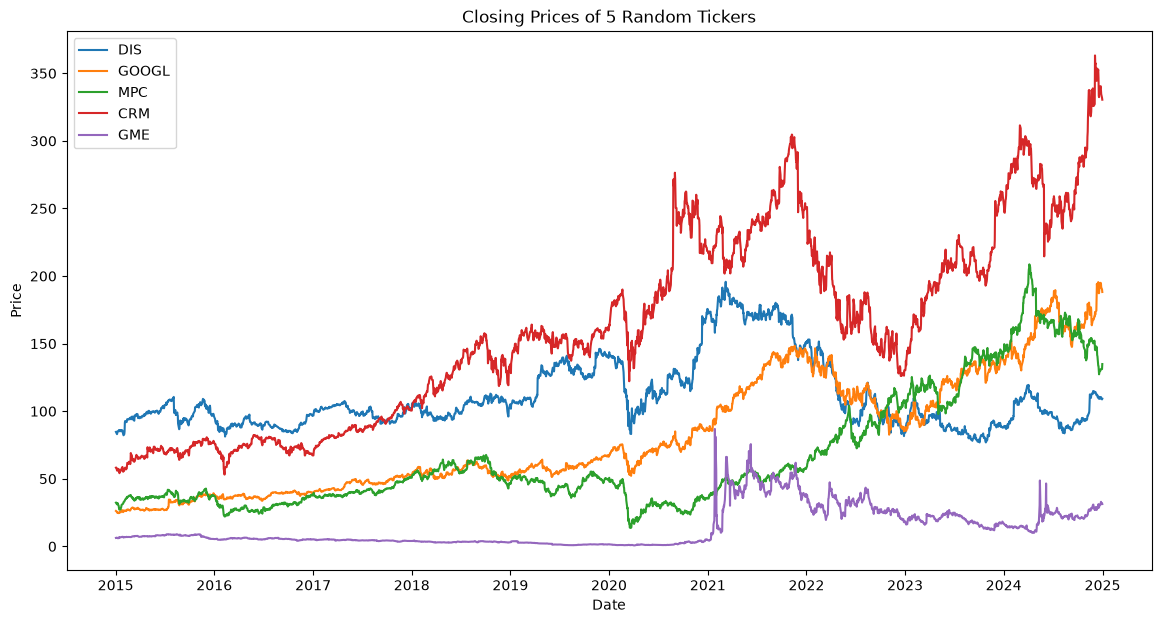

In [7]:
#  Plot the closing prices of the 5 random tickers
plt.figure(figsize=(14, 7))
random_tickers = random.sample(list(df_clean.columns), 5)
for ticker in random_tickers:
    plt.plot(df_clean.index, df_clean[ticker], label=ticker)
plt.title("Closing Prices of 5 Random Tickers")
plt.xlabel("Date")
plt.ylabel("Price")
plt.legend()
plt.show()